# Co-Authorship Network and Research Community Detection
Alex Bradshaw, 1861973

## About
The goal of this analysis is to map co-author relationships across venues.

## Tasks
1. Map co-author networks within and across venues/conferences
2. Use graph clustering to identify research communities/groups
3. Analyze collaboration patterns (do certain author groups dominate certain venues?)

## Motivations
- Identify tight-knit research communities and key bridge figures who connect disparate groups
- Understand collaboration culture: do certain venues/subfields favor collaboration while others are individual-focused?
- Discover hidden research hierarchies: who are the central figures in each community? How do newcomers break in?
- Reveal informal networks: papers often come from established research groups; understanding these networks provides insights into how research is actually conducted

## Challenges
- Author disambiguation: Same name can refer to different authors; misspellings and name variations make exact matching difficult
- Scale variation: Some authors publish 100+ papers, others 1-2; co-authorship graph has highly skewed degree distribution
- Temporal changes: Research communities evolve; some authors exit, new collaborators emerge; static snapshots miss this dynamic
- Defining "communities": Different clustering algorithms (Louvain, K-clique, etc.) can yield very different community structures

In [25]:
"""Import Dependencies"""
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import gc
import community as community_louvain
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from matplotlib.patches import Patch
from itertools import combinations


In [26]:
"""Globals/Constants"""
DATA_PATH = './dblp_ref/'

TOP_N = 25  # number of top venues to visualize in the venue graph
TOP_N_AUTHORS = 25 # number of top authors to visualize in the co-authorship graph

MIN_AUTHOR_PAPERS     = 5   # minimum papers to qualify as a core author
MAX_AUTHORS_PER_PAPER = 10  # caps the author-pair inner loop per paper

MIN_EDGE_WEIGHT = 3   # minimum co-authorship count to keep an edge in the core graph

TOP_COMMUNITIES = 10 # number of top communities to analyze
TOP_AUTHORS_PER_COMMUNITY = 5 # number of top authors to list per community (based on degree centrality) 

TOP_VENUES_T3 = 20  # how many venues to include

In [27]:
"""Helper/Utility Functions"""
def read_json_lines(file_path):
    """Reads the JSON file at the given path and yeilds each line (record)."""
    with open(file_path) as json_file:
        for line in json_file:
            yield json.loads(line)

def load_data_from_file(file_path) -> pd.DataFrame:
    """Loads the data from the given file path and returns a concatenated DataFrame."""
    frames = []
    for file_index in range(4):
        file_name = f'{ file_path }dblp-ref-{ file_index }.json'
        print(f"Loading file { file_name } ({ file_index + 1 }/4)...")
        frames.append(pd.DataFrame(read_json_lines(file_name)))

    print("Concatenating Data Frames...")
    return pd.concat(frames)


In [28]:
"""Load Data"""
# papers = load_data_from_file(DATA_PATH)
papers = pd.read_pickle('cleaned_dataset.pkl')

Pass 1/2: collecting authors per venue…
  3,115 venues
Pass 2/2: counting shared authors between venues…
  2,514,008 venue-pair edges


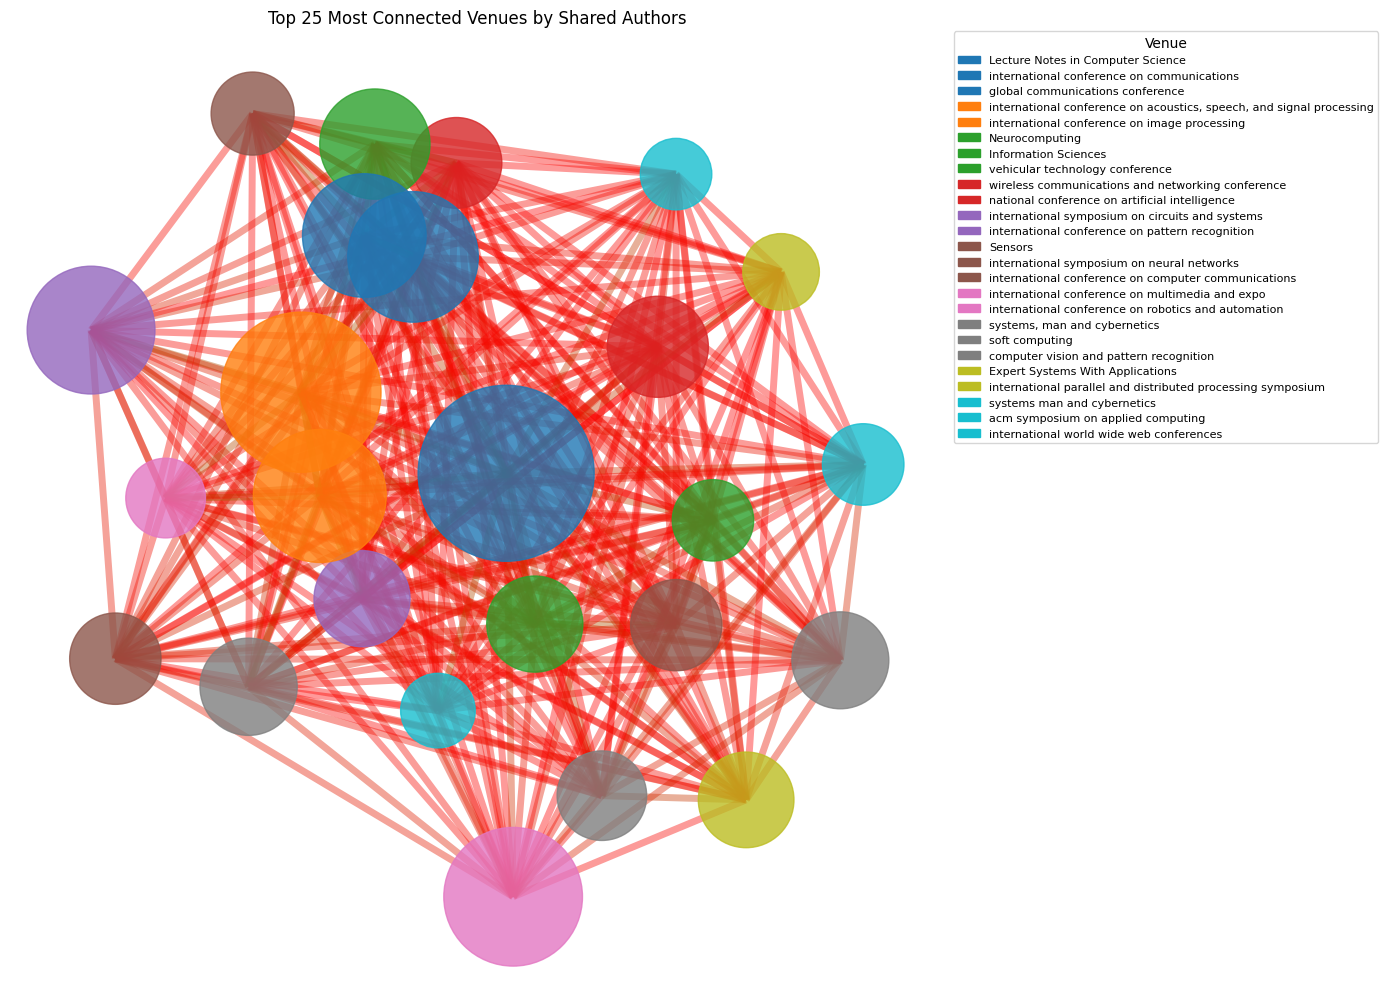

In [29]:
"""Task 1: Map Co-Author Networks Within and Across Venues/Conferences
    
    Task 1.a: Build a graph where nodes are venues and edges connect venues that share authors.
    Edge weight = number of authors who have published in both venues. This surfaces venues that
    are linked through shared researchers.
"""

sample_set = papers[
    papers['venue'].notna()
    & (papers['venue'].astype(str).str.strip() != '')
    & papers['authors'].notna()
]


# Build venue -> set of authors and venue -> paper count in a single pass
print("Pass 1/2: collecting authors per venue…")
venue_authors = defaultdict(set)
venue_paper_count = defaultdict(int)

for paper in sample_set.itertuples():
    venue = paper.venue
    venue_paper_count[venue] += 1
    if isinstance(paper.authors, list):
        for a in paper.authors[:MAX_AUTHORS_PER_PAPER]:
            venue_authors[venue].add(a)

print(f"  {len(venue_authors):,} venues")

# Invert: author -> list of venues they appear in
print("Pass 2/2: counting shared authors between venues…")
author_venues = defaultdict(list)
for v, authors in venue_authors.items():
    for a in authors:
        author_venues[a].append(v)

# Each author who publishes in ≥2 venues contributes +1 to every pair of those venues
edge_weights = defaultdict(int)
for venues in author_venues.values():
    if len(venues) < 2:
        continue
    venues.sort()
    for i in range(len(venues)):
        vi = venues[i]
        for j in range(i + 1, len(venues)):
            edge_weights[(vi, venues[j])] += 1

print(f"  {len(edge_weights):,} venue-pair edges")
del author_venues, venue_authors
gc.collect()

venue_graph = nx.Graph()
for venue, count in venue_paper_count.items():
    venue_graph.add_node(venue, size=count)
for (v1, v2), weight in edge_weights.items():
    venue_graph.add_edge(v1, v2, weight=weight)
del edge_weights
gc.collect()


# Filter to top N venues by weighted degree
scores = {node: venue_graph.degree(node, weight='weight') for node in venue_graph.nodes()}
top_venues = sorted(scores, key=scores.get, reverse=True)[:TOP_N] # type: ignore
subgraph = venue_graph.subgraph(top_venues)

cmap = plt.get_cmap('tab10', TOP_N)
venue_colors = {venue: cmap(i) for i, venue in enumerate(top_venues)}

nodes = list(subgraph.nodes())
max_weight = max((d['weight'] for _, _, d in subgraph.edges(data=True)), default=1)
no_edge_dist = 10.0 / max_weight

layout_graph = nx.complete_graph(len(nodes))
layout_graph = nx.relabel_nodes(layout_graph, dict(enumerate(nodes)))
for u, v in layout_graph.edges():
    if subgraph.has_edge(u, v):
        layout_graph[u][v]['weight'] = 1.0 / subgraph[u][v]['weight']
    else:
        layout_graph[u][v]['weight'] = no_edge_dist

pos = nx.kamada_kawai_layout(layout_graph, weight='weight')

plt.figure(figsize=(14, 10))
node_sizes = [subgraph.nodes[n]['size'] / 2 for n in subgraph.nodes()]
node_colors = [venue_colors[n] for n in subgraph.nodes()]

weights = np.array([subgraph[u][v]['weight'] for u, v in subgraph.edges()], dtype=float)
norm_weights = (weights - weights.min()) / (weights.max() - weights.min()) if weights.max() > weights.min() else np.zeros_like(weights)
edge_colors = [(1 - w, w, 0, 1) for w in norm_weights]

nx.draw_networkx_edges(subgraph, pos, width=5, alpha=0.4, edge_color=edge_colors)
nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, alpha=0.8, node_color=node_colors)

legend_handles = [Patch(color=venue_colors[v], label=v) for v in top_venues]
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8, title='Venue')

plt.title(f'Top {TOP_N} Most Connected Venues by Shared Authors')
plt.axis('off')
plt.tight_layout()
plt.show()


Pass 1/2: counting author publication counts…
  314,847 core authors (≥ 5 papers)
Pass 2/2: counting co-authorship edges…
  2,540,421 unique co-authorship edges
Author graph: 314,847 nodes, 2,540,421 edges


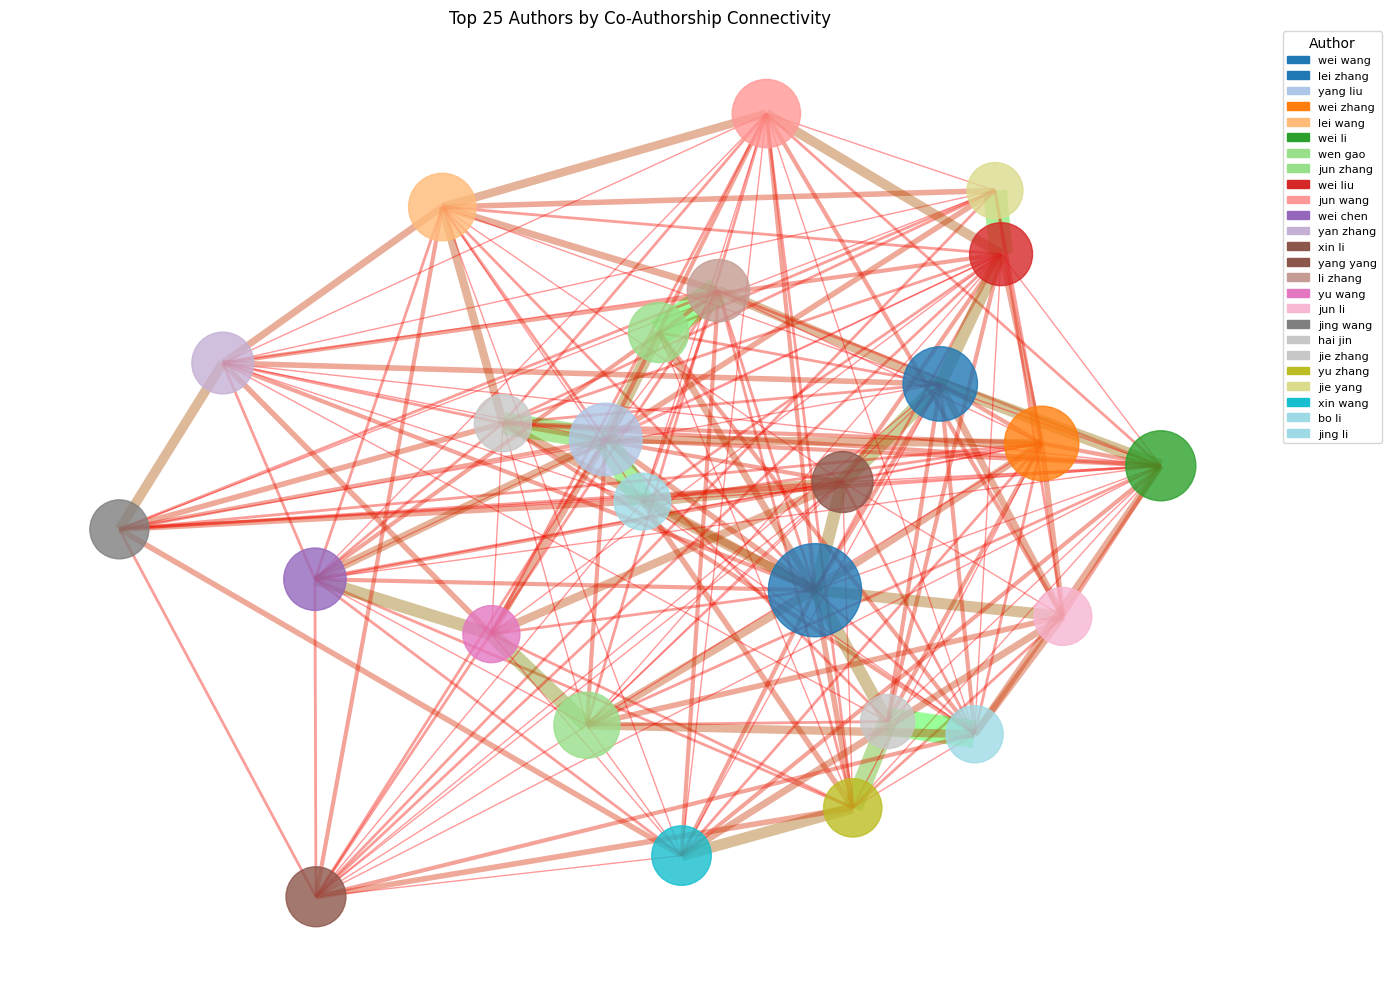

In [ ]:
"""Task 1.b: Build a graph where nodes are authors and edges represent co-authorship (i.e., author A and author B appear on the same paper). Edge weight = number of shared papers. Analyze the graph to identify influential authors and research communities, and visualize the relationships."""

# Pass 1: count publications per author; encode as integers to reduce memory
print("Pass 1/2: counting author publication counts…")
raw_pub_count = defaultdict(int)
for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list):
        continue
    for author in paper.authors[:MAX_AUTHORS_PER_PAPER]:
        raw_pub_count[author] += 1

core_authors_list = [a for a, c in raw_pub_count.items() if c >= MIN_AUTHOR_PAPERS]
author_to_idx     = {a: i for i, a in enumerate(core_authors_list)}
core_pub_counts   = np.array([raw_pub_count[a] for a in core_authors_list], dtype=np.int32)
total_authors = len(raw_pub_count)
del raw_pub_count
gc.collect()
print(f"  {len(author_to_idx):,} core authors (≥ {MIN_AUTHOR_PAPERS} papers) Reduced from {total_authors:,} total authors  ")

# Pass 2: count co-authorship edges (both endpoints must be core authors)
print("Pass 2/2: counting co-authorship edges…")
author_edge_weights = defaultdict(int)
for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list):
        continue
    core = [author_to_idx[a] for a in paper.authors[:MAX_AUTHORS_PER_PAPER]
            if a in author_to_idx]
    if len(core) < 2:
        continue
    core.sort()
    for i, j in combinations(core, 2):
        author_edge_weights[(i, j)] += 1

print(f"  {len(author_edge_weights):,} unique co-authorship edges")
gc.collect()

# Build author graph
author_graph = nx.Graph()
author_graph.add_nodes_from(
    (core_authors_list[i], {'size': int(core_pub_counts[i])})
    for i in range(len(core_authors_list))
)
author_graph.add_edges_from(
    (core_authors_list[i], core_authors_list[j], {'weight': w})
    for (i, j), w in author_edge_weights.items()
)
del author_edge_weights, core_pub_counts
gc.collect()
print(f"Author graph: {author_graph.number_of_nodes():,} nodes, {author_graph.number_of_edges():,} edges")


# Filter to top N authors by weighted degree
author_scores = {node: author_graph.degree(node, weight='weight') for node in author_graph.nodes()}
top_authors = sorted(author_scores, key=author_scores.get, reverse=True)[:TOP_N_AUTHORS] # type: ignore
author_subgraph = author_graph.subgraph(top_authors)

author_cmap = plt.get_cmap('tab20', TOP_N_AUTHORS)
author_colors = {author: author_cmap(i) for i, author in enumerate(top_authors)}

author_max_weight = max((d['weight'] for _, _, d in author_subgraph.edges(data=True)), default=1)
author_no_edge_dist = 10.0 / author_max_weight

author_layout_graph = nx.complete_graph(len(top_authors))
author_layout_graph = nx.relabel_nodes(author_layout_graph, dict(enumerate(top_authors)))
for u, v in author_layout_graph.edges():
    if author_subgraph.has_edge(u, v):
        author_layout_graph[u][v]['weight'] = 1.0 / author_subgraph[u][v]['weight']
    else:
        author_layout_graph[u][v]['weight'] = author_no_edge_dist

author_pos = nx.kamada_kawai_layout(author_layout_graph, weight='weight')
plt.figure(figsize=(14, 10))
author_node_sizes = [author_subgraph.nodes[n]['size'] * 2 for n in author_subgraph.nodes()]
author_edge_raw = np.array([author_subgraph[u][v]['weight'] for u, v in author_subgraph.edges()], dtype=float)
author_edge_widths = [author_subgraph[u][v]['weight'] for u, v in author_subgraph.edges()]
author_norm_weights = (author_edge_raw - author_edge_raw.min()) / (author_edge_raw.max() - author_edge_raw.min()) if author_edge_raw.max() > author_edge_raw.min() else np.zeros_like(author_edge_raw)
author_edge_colors = [(1 - w, w, 0, 1) for w in author_norm_weights]
author_node_colors = [author_colors[n] for n in author_subgraph.nodes()]

nx.draw_networkx_edges(author_subgraph, author_pos, width=author_edge_widths, alpha=0.4, edge_color=author_edge_colors)
nx.draw_networkx_nodes(author_subgraph, author_pos, node_size=author_node_sizes, alpha=0.8, node_color=author_node_colors)

author_legend_handles = [Patch(color=author_colors[a], label=a) for a in top_authors]
plt.legend(handles=author_legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8, title='Author')

plt.title(f'Top {TOP_N_AUTHORS} Authors by Co-Authorship Connectivity')
plt.axis('off')
plt.tight_layout()
plt.show()


Building core graph…
Core graph: 273,507 nodes, 677,097 edges
Running Louvain…

Total communities detected: 8909
Showing top 10 communities by member count:

  Community  1: 10437 authors | hub: mohamed-slim alouini
  Community  2: 10138 authors | hub: erik d. demaine
  Community  3: 9217 authors | hub: wen gao
  Community  4: 6265 authors | hub: hans-peter seidel
  Community  5: 6024 authors | hub: chao wang
  Community  6: 5407 authors | hub: xiaodong wang
  Community  7: 5270 authors | hub: chin-chen chang
  Community  8: 4973 authors | hub: jack dongarra
  Community  9: 4754 authors | hub: nassir navab
  Community 10: 4484 authors | hub: hiroshi ishiguro
Aggregating inter-community edges…


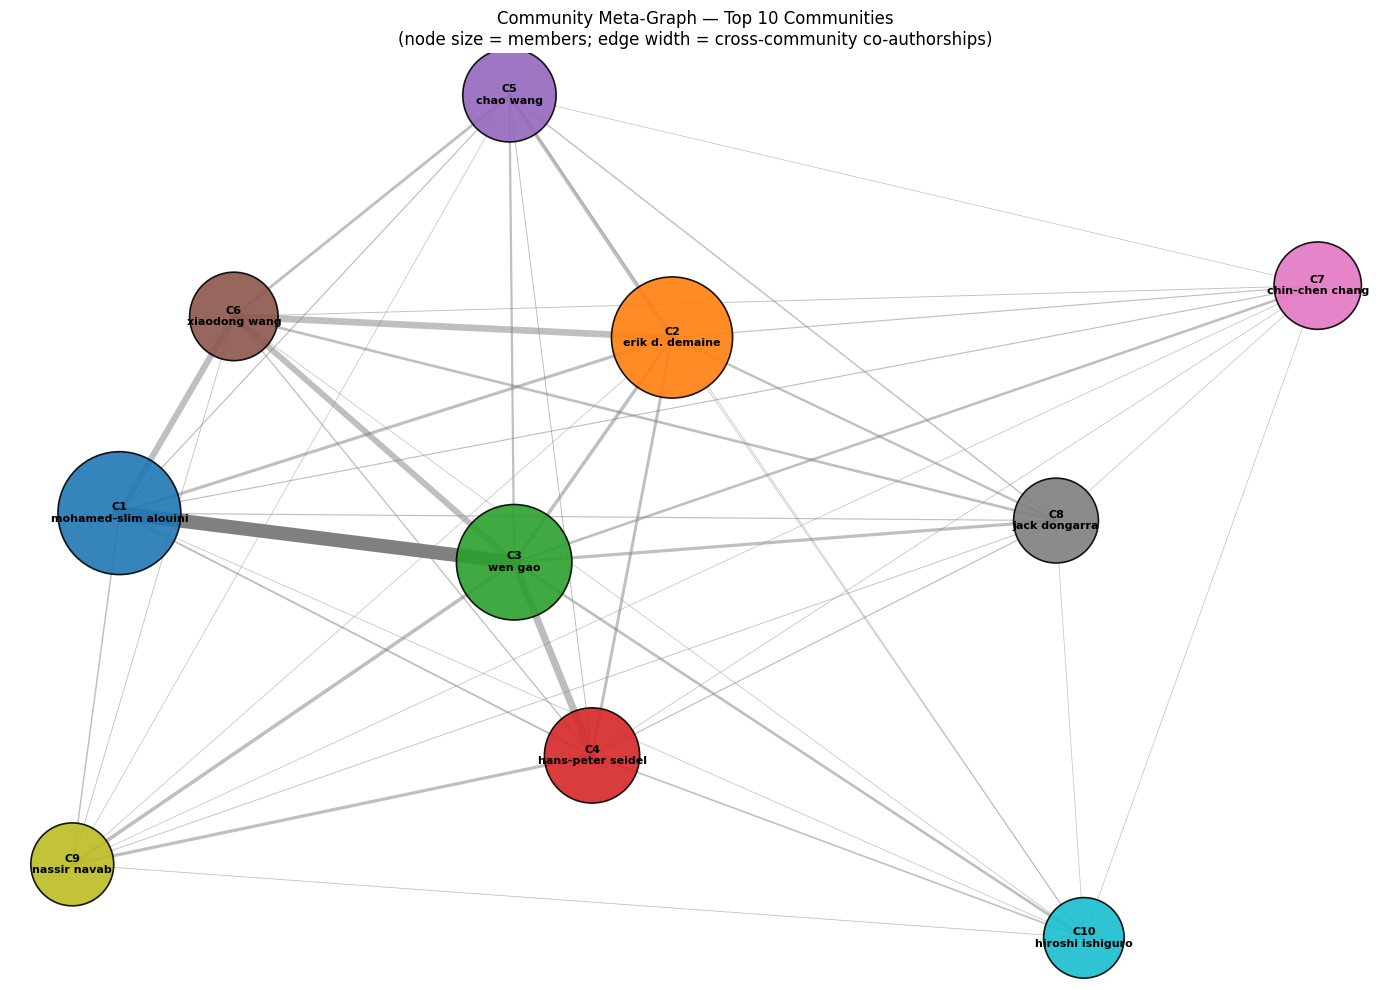

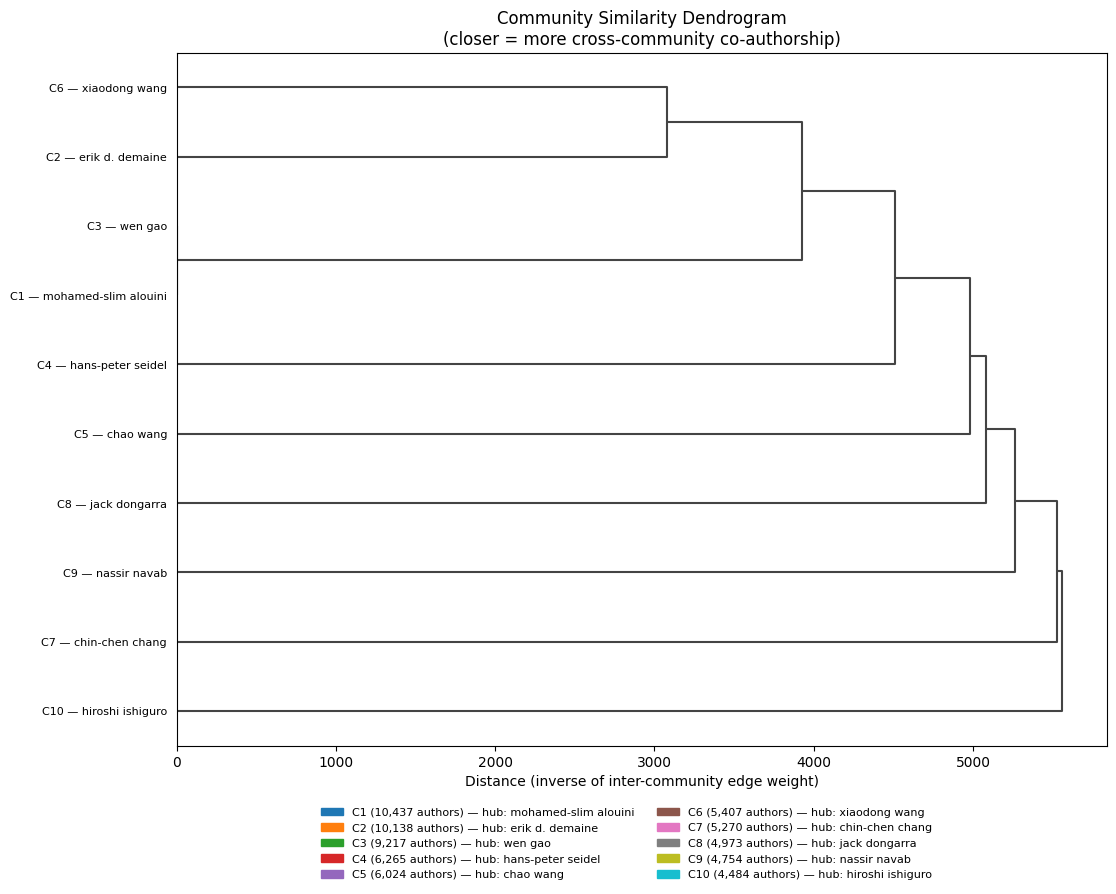


Strongest inter-community bridges (by total co-authorship weight):
  C3  ↔ C1   | weight:    5,931  (wen gao ↔ mohamed-slim alouini)
  C4  ↔ C3   | weight:    3,081  (hans-peter seidel ↔ wen gao)
  C6  ↔ C2   | weight:    2,854  (xiaodong wang ↔ erik d. demaine)
  C6  ↔ C1   | weight:    2,660  (xiaodong wang ↔ mohamed-slim alouini)
  C6  ↔ C3   | weight:    2,560  (xiaodong wang ↔ wen gao)
  C2  ↔ C5   | weight:    1,624  (erik d. demaine ↔ chao wang)
  C9  ↔ C3   | weight:    1,537  (nassir navab ↔ wen gao)
  C2  ↔ C3   | weight:    1,487  (erik d. demaine ↔ wen gao)
  C4  ↔ C9   | weight:    1,368  (hans-peter seidel ↔ nassir navab)
  C3  ↔ C8   | weight:    1,359  (wen gao ↔ jack dongarra)


In [31]:
"""Task 2: Use graph clustering to identify research communities/groups"""

# Build core_graph by streaming qualifying edges
print("Building core graph…")
core_graph = nx.Graph()

core_graph.add_nodes_from(author_graph.nodes(data=True))

# Keep only edges meeting the weight threshold
core_graph.add_edges_from(
    (u, v, d) for u, v, d in author_graph.edges(data=True)
    if d.get('weight', 0) >= MIN_EDGE_WEIGHT
)

# Drop isolated nodes
core_graph.remove_nodes_from(list(nx.isolates(core_graph)))

del author_graph
gc.collect()

print(f"Core graph: {core_graph.number_of_nodes():,} nodes, {core_graph.number_of_edges():,} edges")

# Run Louvain community detection
print("Running Louvain…")
partition = community_louvain.best_partition(core_graph, weight='weight', random_state=42)

# community id -> member list
communities = {}
for author, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(author)

top_comm_ids = sorted(communities, key=lambda c: len(communities[c]), reverse=True)[:TOP_COMMUNITIES]

print(f"\nTotal communities detected: {len(communities)}")
print(f"Showing top {TOP_COMMUNITIES} communities by member count:\n")
for rank, cid in enumerate(top_comm_ids, 1):
    members = communities[cid]
    hub = max(members, key=lambda a: core_graph.degree(a, weight='weight'))
    print(f"  Community {rank:>2}: {len(members):>4} authors | hub: {hub}")


# Build community meta-graph: aggregate every cross-community edge in core_graph
# into a single weighted edge between the two communities. Also tally intra-community
# edge weight (used to normalise and to size nodes by internal collaboration density).
print("Aggregating inter-community edges…")
top_set = {cid: rank for rank, cid in enumerate(top_comm_ids, 1)}
inter_weights = defaultdict(int)
intra_weights = defaultdict(int)
for u, v, d in core_graph.edges(data=True):
    cu = partition.get(u)
    cv = partition.get(v)
    if cu not in top_set or cv not in top_set:
        continue
    w = d.get('weight', 1)
    if cu == cv:
        intra_weights[cu] += w
    else:
        key = (cu, cv) if cu < cv else (cv, cu) # type: ignore
        inter_weights[key] += w

# Hub author per top community (for labelling)
comm_hub = {
    cid: max(communities[cid], key=lambda a: core_graph.degree(a, weight='weight'))
    for cid in top_comm_ids
}

# Define color map for communities
comm_cmap = plt.get_cmap('tab10', max(1, len(top_comm_ids)))
comm_color_map = {cid: comm_cmap(i) for i, cid in enumerate(top_comm_ids)}

# Plot 1: Community meta-graph
fig_net = plt.figure(figsize=(14, 10))
ax_net = fig_net.add_subplot(111)

meta = nx.Graph()
for cid in top_comm_ids:
    meta.add_node(cid,
                  size=len(communities[cid]),
                  intra=intra_weights.get(cid, 0))
for (a, b), w in inter_weights.items():
    meta.add_edge(a, b, weight=w)

meta_pos = nx.spring_layout(meta, weight='weight', seed=42, k=1.6, iterations=200)

meta_node_sizes = [meta.nodes[c]['size'] * 0.75 for c in meta.nodes()]
meta_node_colors = [comm_color_map[c] for c in meta.nodes()] # type: ignore

if meta.number_of_edges():
    meta_edges = list(meta.edges(data=True))
    meta_edge_w = np.array([d['weight'] for _, _, d in meta_edges], dtype=float)
    # Width: linear scaled; Alpha: emphasise strongest links
    meta_edge_widths = np.clip(meta_edge_w / meta_edge_w.max() * 10, 0.5, 10)
    meta_edge_alphas = np.clip(meta_edge_w / meta_edge_w.max(), 0.5, 1)
    for (u, v, _), wd, al in zip(meta_edges, meta_edge_widths, meta_edge_alphas):
        ax_net.plot(
            [meta_pos[u][0], meta_pos[v][0]],
            [meta_pos[u][1], meta_pos[v][1]],
            color='gray', linewidth=wd, alpha=al, zorder=1,
        )

nx.draw_networkx_nodes(meta, meta_pos, node_size=meta_node_sizes,
                       node_color=meta_node_colors, alpha=0.9,
                       edgecolors='black', linewidths=1.2, ax=ax_net)

labels = {cid: f"C{top_set[cid]}\n{comm_hub[cid]}" for cid in meta.nodes()}
nx.draw_networkx_labels(meta, meta_pos, labels=labels, font_size=8,
                        font_weight='bold', ax=ax_net)

ax_net.set_title(
    f'Community Meta-Graph \u2014 Top {TOP_COMMUNITIES} Communities'
    f'\n(node size = members; edge width = cross-community co-authorships)',
    fontsize=12,
)
ax_net.axis('off')
fig_net.tight_layout()
plt.show()

# Plot 2: Dendrogram of communities clustered by inter-community connection strength
fig_dend = plt.figure(figsize=(12, 9))
ax_dend = fig_dend.add_subplot(111)

n = len(top_comm_ids)
sim = np.zeros((n, n), dtype=float)
for (a, b), w in inter_weights.items():
    i, j = top_set[a] - 1, top_set[b] - 1
    sim[i, j] = sim[j, i] = w

max_sim = sim.max() if sim.max() > 0 else 1.0
dist = max_sim + 1.0 - sim
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method='average')

dend_labels = [f"C{top_set[cid]} \u2014 {comm_hub[cid]}" for cid in top_comm_ids]
dendrogram(
    Z, labels=dend_labels, orientation='right',
    leaf_font_size=9, color_threshold=0, above_threshold_color='#444',
    ax=ax_dend,
)
ax_dend.set_title(
    'Community Similarity Dendrogram\n(closer = more cross-community co-authorship)',
    fontsize=12,
)
ax_dend.set_xlabel('Distance (inverse of inter-community edge weight)')
ax_dend.tick_params(axis='y', labelsize=8)

legend_handles = [
    Patch(color=comm_color_map[cid], # type: ignore
          label=f"C{top_set[cid]} ({len(communities[cid]):,} authors) \u2014 hub: {comm_hub[cid]}")
    for cid in top_comm_ids
]
fig_dend.legend(handles=legend_handles, loc='lower center', ncol=2,
                bbox_to_anchor=(0.5, -0.05), fontsize=8, frameon=False)


plt.show()

# Print top inter-community bridges
print("\nStrongest inter-community bridges (by total co-authorship weight):")
for (a, b), w in sorted(inter_weights.items(), key=lambda kv: kv[1], reverse=True)[:10]:
    print(f"  C{top_set[a]:<2} \u2194 C{top_set[b]:<2}  | weight: {w:>8,}  "
          f"({comm_hub[a]} \u2194 {comm_hub[b]})")



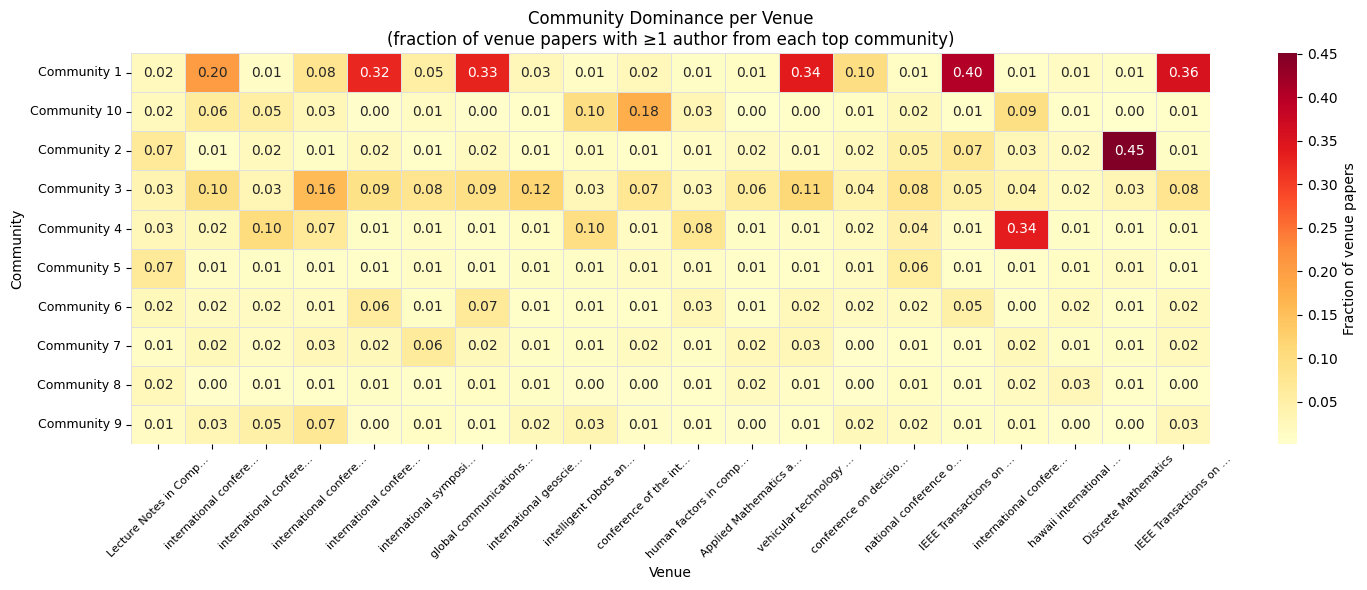

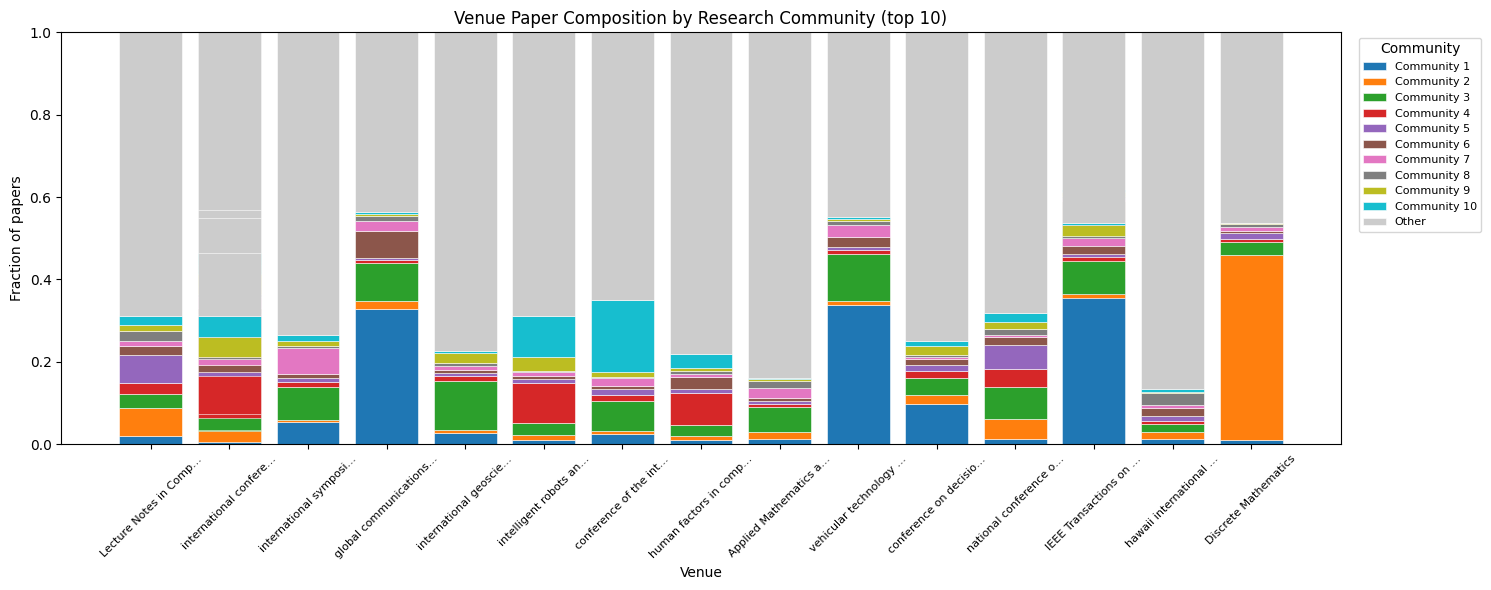

Dominant community per venue (by fraction):

  Lecture Notes in Comp…    →  Community 2  (6.7% of 32,137 papers)
  international confere…    →  Community 1  (20.4% of 26,621 papers)
  international confere…    →  Community 4  (10.3% of 19,943 papers)
  international confere…    →  Community 3  (15.6% of 18,336 papers)
  international confere…    →  Community 1  (32.5% of 17,679 papers)
  international symposi…    →  Community 3  (8.0% of 16,945 papers)
  global communications…    →  Community 1  (32.9% of 15,850 papers)
  international geoscie…    →  Community 3  (11.8% of 15,390 papers)
  intelligent robots an…    →  Community 10  (9.9% of 14,698 papers)
  conference of the int…    →  Community 10  (17.6% of 13,510 papers)
  human factors in comp…    →  Community 4  (7.8% of 13,120 papers)
  Applied Mathematics a…    →  Community 3  (6.1% of 13,060 papers)
  vehicular technology …    →  Community 1  (33.8% of 12,605 papers)
  conference on decisio…    →  Community 1  (9.9% of 12,139 p

In [32]:
"""Task 3: Analyze collaboration patterns: do certain author groups dominate certain venues?"""
# Map each author (in the top communities) to a readable label
author_to_comm_label = {}
for rank, cid in enumerate(top_comm_ids, 1):
    for a in communities[cid]:
        author_to_comm_label[a] = f"Community {rank}"

# Work with papers that have a valid venue and at least one author
valid = (
    sample_set['venue'].notna()
    & (sample_set['venue'].astype(str).str.strip() != '')
    & sample_set['authors'].notna()
)
working = sample_set.loc[valid, ['id', 'venue', 'authors']].copy()

# Choose the top N venues by paper count
venue_totals = working.groupby('venue').size()
top_venue_list = venue_totals.nlargest(TOP_VENUES_T3).index.tolist()
working = working[working['venue'].isin(top_venue_list)]

# Explode so each row is (paper_id, venue, author), map to community label
exploded = working.explode('authors').rename(columns={'authors': 'author'})
exploded['community'] = exploded['author'].map(author_to_comm_label)
exploded = exploded.dropna(subset=['community'])

# Deduplicate: count each (paper, community) pair only once
# (avoids inflating when several co-authors belong to the same community)
unique_pairs = exploded.drop_duplicates(subset=['id', 'community'])

# Build community × venue count matrix, then normalise by venue total
count_matrix = (
    unique_pairs.groupby(['community', 'venue'])
    .size()
    .unstack('venue', fill_value=0)
    .reindex(columns=top_venue_list, fill_value=0)
)
norm_matrix = count_matrix.divide(venue_totals[top_venue_list], axis=1)

# Shorten long venue names so they fit on axes
def _shorten(name, n=22):
    return name if len(name) <= n else name[: n - 1] + "…"

short_venues = [_shorten(v) for v in top_venue_list]
norm_matrix.columns = short_venues
count_matrix.columns = short_venues

#  Plot 1: Heatmap: fraction of each venue's papers authored by each community 
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    norm_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Fraction of venue papers"},
    ax=ax,
)
ax.set_title(
    "Community Dominance per Venue\n"
    "(fraction of venue papers with ≥1 author from each top community)",
    fontsize=12,
)
ax.set_xlabel("Venue", fontsize=10)
ax.set_ylabel("Community", fontsize=10)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()


#  Plot 2: Stacked bar: per-venue paper share broken down by community 
community_labels = [f"Community {r}" for r in range(1, TOP_COMMUNITIES + 1)]

bar_cmap = plt.get_cmap("tab10", TOP_COMMUNITIES)
colors = {f"Community {r}": bar_cmap(r - 1) for r in range(1, TOP_COMMUNITIES + 1)}
colors["Other"] = "#cccccc" # type: ignore

# "Other" absorbs the remainder so bars sum to 1
other_row = (1.0 - norm_matrix.sum(axis=0)).clip(lower=0)
plot_df = norm_matrix.reindex(community_labels, fill_value=0)
plot_df.loc["Other"] = other_row

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(short_venues))
for label in community_labels + ["Other"]:
    vals = plot_df.loc[label].values.astype(float)
    ax.bar(short_venues, vals, bottom=bottom,
           color=colors[label], label=label, edgecolor="white", linewidth=0.4)
    bottom += vals

ax.set_title(
    f"Venue Paper Composition by Research Community (top {TOP_COMMUNITIES})",
    fontsize=12,
)
ax.set_xlabel("Venue", fontsize=10)
ax.set_ylabel("Fraction of papers", fontsize=10)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, title="Community")
plt.tight_layout()
plt.show()


#  Summary: dominant community per venue 
print("Dominant community per venue (by fraction):\n")
for col_idx, (short, full) in enumerate(zip(short_venues, top_venue_list)):
    col_data = norm_matrix.iloc[:, col_idx]
    dominant = col_data.idxmax()
    frac = float(col_data.max())
    total = int(venue_totals[full])
    print(f"  {short:<24}  →  {dominant}  ({frac:.1%} of {total:,} papers)")
